<a href="https://colab.research.google.com/github/qvinh28/CV2/blob/main/Gradient_Domain_Editing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHẦN 1: Gradient Domain Editing

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src_img = cv2.imread('images/balloon.jpg')
src_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)

bg_img = cv2.imread('images/eversest.jpg')
bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)

Hiển thị ảnh gốc

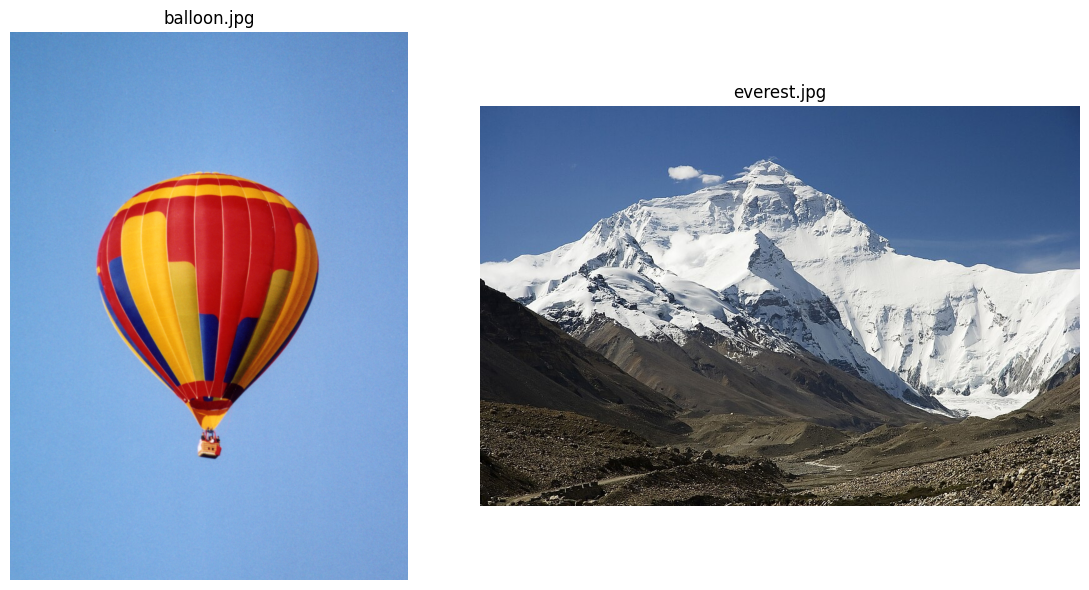

In [ ]:
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.imshow(src_img)
plt.title('balloon.jpg')
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(bg_img)
plt.title('everest.jpg')
plt.axis('off')

plt.tight_layout()
plt.show()

Tạo MASK khinh khí cầu

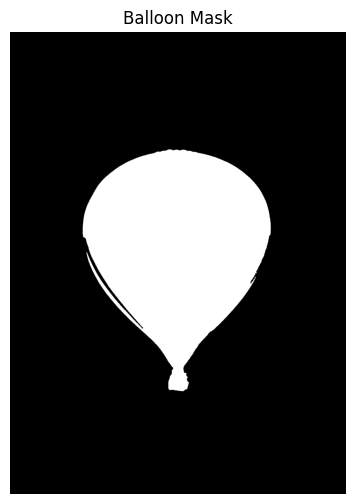

In [ ]:
hsv_img = cv2.cvtColor(src_img, cv2.COLOR_RGB2HSV)
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

sky_mask = cv2.inRange(hsv_img, lower_blue, upper_blue)
balloon_mask = cv2.bitwise_not(sky_mask)

kernel = np.ones((5, 5), np.uint8)
balloon_mask = cv2.morphologyEx(balloon_mask, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(balloon_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
tight_mask = np.zeros_like(balloon_mask)
cv2.drawContours(tight_mask, [largest_contour], -1, 255, -1)

plt.figure(figsize=(6, 6))
plt.imshow(tight_mask, cmap='gray')
plt.title('Balloon Mask')
plt.axis('off')
plt.show()

Cắt ảnh

In [ ]:
x, y, w, h = cv2.boundingRect(largest_contour)

margin = 40
y1 = max(0, y - margin)
y2 = min(src_img.shape[0], y + h + margin)
x1 = max(0, x - margin)
x2 = min(src_img.shape[1], x + w + margin)

balloon_crop = src_img[y1:y2, x1:x2]
tight_mask_crop = tight_mask[y1:y2, x1:x2]

crop_h, crop_w = balloon_crop.shape[:2]

scale_percent = 10
new_w = int(crop_w * scale_percent / 100)
new_h = int(crop_h * scale_percent / 100)
dim = (new_w, new_h)

balloon_crop = cv2.resize(balloon_crop, dim, interpolation=cv2.INTER_AREA)
tight_mask_crop = cv2.resize(tight_mask_crop, dim, interpolation=cv2.INTER_NEAREST)


Tạo MASK cho SEAMLESS CLONE (opencv2)

In [ ]:
kernel_dilate = np.ones((10, 10), np.uint8)
loose_mask_crop = cv2.dilate(tight_mask_crop, kernel_dilate, iterations=1)

Ghép ảnh và hiển thị ảnh

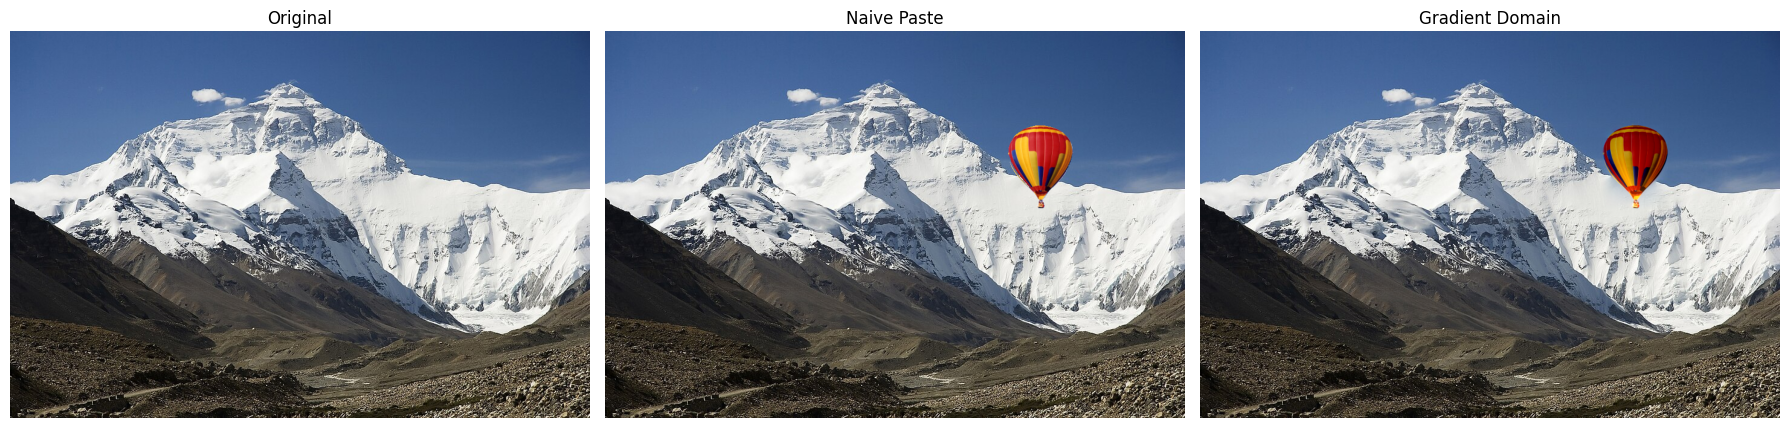

In [ ]:
bg_h, bg_w = bg_img.shape[:2]

center_x = int(bg_w * 0.75)
center_y = int(bg_h * 0.35)
center = (center_x, center_y)


naive_result = bg_img.copy()
start_y = center_y - new_h // 2
start_x = center_x - new_w // 2

for i in range(new_h):
    for j in range(new_w):
        if tight_mask_crop[i, j] == 255:
            if 0 <= start_y + i < bg_h and 0 <= start_x + j < bg_w:
                naive_result[start_y + i, start_x + j] = balloon_crop[i, j]

seamless_result = cv2.seamlessClone(balloon_crop, bg_img, loose_mask_crop, center, cv2.NORMAL_CLONE)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(bg_img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(naive_result)
plt.title('Naive Paste')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(seamless_result)
plt.title('Gradient Domain')
plt.axis('off')

plt.tight_layout()
plt.show()